# 03 — Tier 1 Feature Extraction (Composition-Only)

**Goal**: Extract physics-informed features from chemical formulas for all entries.

These features capture:
- **Carrier concentration**: How much Li is available to conduct
- **Anion framework chemistry**: How tightly the framework grips Li⁺
- **Channel geometry proxies**: How large the gaps are for Li to move through
- **Composition complexity**: Empirical patterns in good conductors

Applied to `comp_train.csv` (861 entries) and `comp_test.csv` (121 entries).
Also applied to `struct_train.csv` and `struct_test.csv` for later use.

**Prerequisites**: Run notebooks 01 and 02 first.

In [1]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition, Element
import warnings
warnings.filterwarnings('ignore')

## Step 1: Define feature extraction

Every feature comes from known physical constants (electronegativity, ionic radius, atomic mass) 
combined with the composition's stoichiometry. Pymatgen has all the periodic table data built in.

In [2]:
def identify_anions(comp):
    """Identify anion elements in a composition.
    Anions are the most electronegative elements — typically O, S, F, Cl, Br, I, N, Se."""
    anion_candidates = {'O', 'S', 'F', 'Cl', 'Br', 'I', 'N', 'Se', 'Te'}
    anions = []
    for el in comp.elements:
        if el.symbol in anion_candidates:
            anions.append(el)
    return anions if anions else [max(comp.elements, key=lambda e: e.X)]

def identify_cations(comp, anions):
    """Everything that isn't an anion is a cation."""
    anion_symbols = {a.symbol for a in anions}
    return [el for el in comp.elements if el.symbol not in anion_symbols]

def get_anion_type(anions):
    """Classify the anion framework: oxide, sulfide, halide, or mixed."""
    symbols = {a.symbol for a in anions}
    halogens = {'F', 'Cl', 'Br', 'I'}
    
    has_oxide = 'O' in symbols
    has_sulfide = 'S' in symbols
    has_halide = bool(symbols & halogens)
    
    types = []
    if has_oxide: types.append('oxide')
    if has_sulfide: types.append('sulfide')
    if has_halide: types.append('halide')
    
    if len(types) == 0:
        return 'other'
    elif len(types) == 1:
        return types[0]
    else:
        return 'mixed'

def get_ionic_radius(element, default=1.0):
    """Get the most common ionic radius for an element.
    Shannon radii depend on charge and coordination — we use the most common charge state."""
    try:
        # common_oxidation_states gives the most typical charges
        common_charges = element.common_oxidation_states
        if common_charges:
            # Try the most common charge first
            for charge in common_charges:
                if charge in element.ionic_radii:
                    return element.ionic_radii[charge]
        # Fallback: try any available ionic radius
        if element.ionic_radii:
            return list(element.ionic_radii.values())[0]
    except Exception:
        pass
    return default

def extract_composition_features(formula_string):
    """Extract Tier 1 features from a composition string.
    Returns a dict of feature_name: value."""
    try:
        comp = Composition(formula_string)
    except Exception:
        return None
    
    total_atoms = comp.num_atoms
    elements = comp.elements
    amounts = [comp[el] for el in elements]  # number of each element
    
    # Identify anions and cations
    anions = identify_anions(comp)
    cations = identify_cations(comp, anions)
    
    # --- Carrier features ---
    li_amount = comp['Li'] if Element('Li') in elements else 0
    li_fraction = li_amount / total_atoms
    
    # --- Electronegativity features ---
    electronegativities = [el.X for el in elements]
    en_weighted = sum(comp[el] * el.X for el in elements) / total_atoms
    
    anion_en = max(a.X for a in anions) if anions else 0
    cation_en_weighted = (
        sum(comp[el] * el.X for el in cations) / sum(comp[el] for el in cations)
        if cations else 0
    )
    en_difference = anion_en - cation_en_weighted
    
    # --- Ionic radius features ---
    radii = {el: get_ionic_radius(el) for el in elements}
    mean_radius = sum(comp[el] * radii[el] for el in elements) / total_atoms
    anion_radius = max(radii[a] for a in anions) if anions else 0
    
    # --- Mass features ---
    mean_mass = sum(comp[el] * el.atomic_mass for el in elements) / total_atoms
    
    # --- Composition complexity ---
    n_elements = len(elements)
    anion_type = get_anion_type(anions)
    mean_atomic_number = sum(comp[el] * el.Z for el in elements) / total_atoms
    
    # --- Variance/range features (capture spread in properties) ---
    en_std = np.std([el.X for el in elements for _ in range(int(comp[el]))])
    radius_std = np.std([radii[el] for el in elements for _ in range(int(comp[el]))])
    
    return {
        # Carrier
        'li_fraction': li_fraction,
        'li_count': li_amount,
        # Electronegativity
        'mean_electronegativity': en_weighted,
        'anion_electronegativity': anion_en,
        'cation_anion_en_diff': en_difference,
        'en_std': en_std,
        # Ionic radius
        'mean_ionic_radius': mean_radius,
        'anion_ionic_radius': anion_radius,
        'radius_std': radius_std,
        # Mass
        'mean_atomic_mass': float(mean_mass),
        # Complexity
        'n_elements': n_elements,
        'mean_atomic_number': mean_atomic_number,
        # Anion type (will be one-hot encoded later)
        'anion_type': anion_type,
    }

## Step 2: Extract features for all datasets

In [3]:
def featurize_dataset(df, label):
    """Apply composition feature extraction to a dataframe."""
    print(f"Extracting features for {label} ({len(df)} entries)...")
    
    features = []
    failed = []
    for idx, row in df.iterrows():
        feat = extract_composition_features(row['composition'])
        if feat is None:
            failed.append(row['composition'])
            features.append({})
        else:
            features.append(feat)
    
    feat_df = pd.DataFrame(features)
    
    if failed:
        print(f"  WARNING: {len(failed)} compositions failed to parse")
        print(f"  Examples: {failed[:5]}")
    
    # One-hot encode anion_type
    if 'anion_type' in feat_df.columns:
        dummies = pd.get_dummies(feat_df['anion_type'], prefix='anion')
        feat_df = pd.concat([feat_df.drop('anion_type', axis=1), dummies], axis=1)
    
    print(f"  Extracted {len(feat_df.columns)} features")
    return feat_df

# Load all four datasets
comp_train = pd.read_csv('comp_train.csv')
comp_test = pd.read_csv('comp_test.csv')
struct_train = pd.read_csv('struct_train.csv')
struct_test = pd.read_csv('struct_test.csv')

# Extract features
comp_train_feat = featurize_dataset(comp_train, 'comp_train')
comp_test_feat = featurize_dataset(comp_test, 'comp_test')
struct_train_feat = featurize_dataset(struct_train, 'struct_train')
struct_test_feat = featurize_dataset(struct_test, 'struct_test')

Extracting features for comp_train (861 entries)...
  Examples: ['"(Li2S)0.5 ((P2S5)0.4 (Sb2S3)0.6)0.5"', '"(Li2S)0.3 ((P2S5)0.4 (Sb2S3)0.6)0.7"', '"(Li2S)0.4 ((P2S5)0.4 (Sb2S3)0.6)0.6"', '"(LiCl)0.5 (P2O5)0.5"', '"(Li2O)50 (Al2O3)2 (P2O5)48"']
  Extracted 17 features
Extracting features for comp_test (121 entries)...
  Examples: ['Li3(Mo8S8O8(OH)8(HWO5(H2O)))*(H2O)18']
  Extracted 17 features
Extracting features for struct_train (339 entries)...
  Extracted 17 features
Extracting features for struct_test (69 entries)...
  Examples: ['Li3(Mo8S8O8(OH)8(HWO5(H2O)))*(H2O)18']
  Extracted 17 features


## Step 3: Inspect extracted features

In [4]:
print("=== Feature columns ===")
print(comp_train_feat.columns.tolist())

print(f"\n=== comp_train feature stats ===")
display(comp_train_feat.describe().round(3))

print(f"\n=== Sample rows ===")
sample = pd.concat([comp_train[['id','composition','log_conductivity']], comp_train_feat], axis=1)
display(sample.head(10))

=== Feature columns ===
['li_fraction', 'li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'en_std', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide']

=== comp_train feature stats ===


,li_fraction,li_count,mean_electronegativity,anion_electronegativity,cation_anion_en_diff,en_std,mean_ionic_radius,anion_ionic_radius,radius_std,mean_atomic_mass,n_elements,mean_atomic_number
count,829.000,829.000,829.000,829.000,829.000,826.000,829.000,829.000,826.000,829.000,829.000,829.000
mean,0.232,3.422,2.410,3.275,1.893,0.875,1.126,1.392,0.267,27.911,4.526,12.778
std,0.163,2.736,0.396,0.346,0.368,0.262,0.088,0.245,0.108,9.596,0.811,3.838
min,0.011,0.022,1.282,2.190,0.690,0.000,0.774,0.580,0.000,3.631,2.000,2.000
25%,0.071,1.200,2.112,3.160,1.677,0.783,1.070,1.260,0.184,21.418,4.000,10.355
50%,0.231,2.400,2.385,3.440,1.807,0.812,1.111,1.260,0.267,24.285,5.000,11.556
75%,0.394,6.000,2.832,3.440,2.220,1.135,1.148,1.670,0.317,35.806,5.000,15.846
max,0.750,17.000,2.961,3.980,3.000,1.500,1.609,2.070,0.580,94.951,6.000,39.500



=== Sample rows ===


,id,composition,log_conductivity,li_fraction,li_count,mean_electronegativity,anion_electronegativity,cation_anion_en_diff,en_std,mean_ionic_radius,anion_ionic_radius,radius_std,mean_atomic_mass,n_elements,mean_atomic_number,anion_halide,anion_mixed,anion_other,anion_oxide,anion_sulfide
0,jqc,Li7BiO6,-5.800001,0.500000,7.00,2.108571,3.44,2.330000,1.182001,1.073571,1.26,0.174994,25.254557,3.0,10.857143,False,False,False,True,False
1,oi6,Li7SbO6,-7.173925,0.500000,7.00,2.110714,3.44,2.326250,1.181866,1.054286,1.26,0.178154,19.024529,3.0,8.571429,False,False,False,True,False
2,2t8,LiV(PO4)F,-6.091515,0.125000,1.00,2.817500,3.98,2.380000,1.005096,1.048750,1.26,0.268395,21.481533,5.0,10.250000,False,True,False,False,False
3,47i,Li4P2O7,-10.000000,0.307692,4.00,2.490769,3.44,2.056667,1.096073,1.044615,1.26,0.254214,15.515948,3.0,7.538462,False,False,False,True,False
4,clt,Li6CuB4O10,-13.000000,0.285714,6.00,2.397143,3.44,1.990909,1.061953,0.976667,1.26,0.318767,14.687143,4.0,7.000000,False,False,False,True,False
5,ix1,Li0.91Hf2.022(PO4)3,-6.494850,0.050747,0.91,2.864733,3.44,1.738989,0.769022,1.081737,1.26,0.270321,36.367230,4.0,16.133950,False,False,False,True,False
6,bq9,Li3BiO3,-9.619789,0.428571,3.00,2.182857,3.44,2.200000,1.140698,1.092857,1.26,0.169597,39.685943,3.0,16.571429,False,False,False,True,False
7,skm,Li5BiO5,-8.408935,0.454545,5.00,2.192727,3.44,2.286667,1.174030,1.088182,1.26,0.173563,29.425673,3.0,12.545455,False,False,False,True,False
8,pwr,Li7.22Si1.5P0.5O8,-6.785156,0.419280,7.22,2.238130,3.44,2.244707,1.192075,1.026597,1.26,0.219303,13.688987,4.0,6.629501,False,False,False,True,False
9,b4c,Li4SiS4,-7.798603,0.444444,4.00,1.793333,2.58,1.416000,0.755189,1.215556,1.70,0.446396,20.456611,3.0,10.000000,False,False,False,False,True


In [5]:
# Check for NaN features
nan_counts = comp_train_feat.isna().sum()
if nan_counts.any():
    print("Features with NaN values:")
    print(nan_counts[nan_counts > 0])
else:
    print("✓ No NaN values in features")

# Check anion type distribution
anion_cols = [c for c in comp_train_feat.columns if c.startswith('anion_')]
print(f"\nAnion type distribution (train):")
for col in anion_cols:
    print(f"  {col}: {comp_train_feat[col].sum():.0f}")

Features with NaN values:
li_fraction                32
li_count                   32
mean_electronegativity     32
anion_electronegativity    32
cation_anion_en_diff       32
en_std                     35
mean_ionic_radius          32
anion_ionic_radius         32
radius_std                 35
mean_atomic_mass           32
n_elements                 32
mean_atomic_number         32
dtype: int64

Anion type distribution (train):
  anion_electronegativity: 2715
  anion_ionic_radius: 1154
  anion_halide: 22
  anion_mixed: 105
  anion_other: 17
  anion_oxide: 580
  anion_sulfide: 105


## Step 4: Quick sanity check — do features correlate with conductivity?

Feature correlations with log(conductivity):
en_std                    -0.235
anion_electronegativity   -0.227
cation_anion_en_diff      -0.214
mean_electronegativity    -0.108
li_fraction               -0.003
mean_atomic_mass           0.103
mean_atomic_number         0.121
radius_std                 0.153
anion_ionic_radius         0.192
li_count                   0.195
mean_ionic_radius          0.244
n_elements                 0.385
dtype: float64


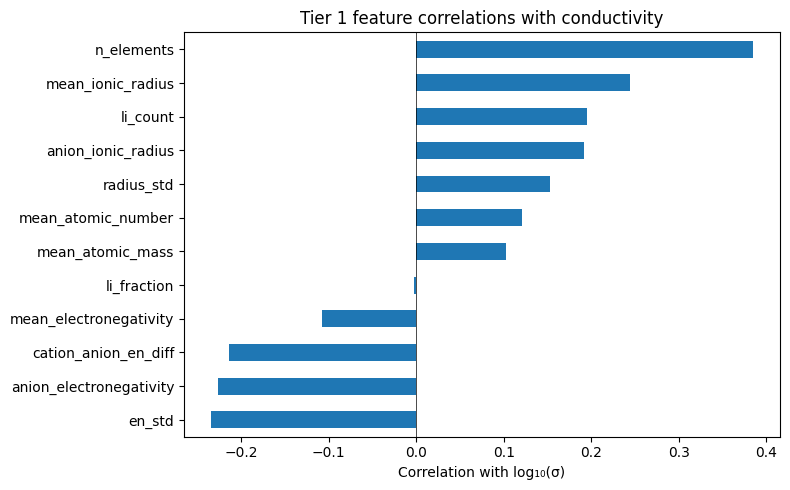

In [6]:
import matplotlib.pyplot as plt

# Correlations with target
numeric_feat = comp_train_feat.select_dtypes(include=[np.number])
target = comp_train['log_conductivity']

correlations = numeric_feat.corrwith(target).sort_values()
print("Feature correlations with log(conductivity):")
print(correlations.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax)
ax.set_xlabel('Correlation with log₁₀(σ)')
ax.set_title('Tier 1 feature correlations with conductivity')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 5: Save feature matrices

In [10]:
# Combine features with IDs and targets for easy loading later
def save_featured(df_orig, df_feat, filename):
    out = pd.concat([
        df_orig[['id', 'composition', 'log_conductivity']].reset_index(drop=True),
        df_feat.reset_index(drop=True)
    ], axis=1)
    out.to_csv(filename, index=False)
    return out

save_featured(comp_train, comp_train_feat, 'comp_train_features.csv')
save_featured(comp_test, comp_test_feat, 'comp_test_features.csv')
save_featured(struct_train, struct_train_feat, 'struct_train_features.csv')
save_featured(struct_test, struct_test_feat, 'struct_test_features.csv')

print("Saved:")
print(f"  comp_train_features.csv    ({len(comp_train)} × {len(comp_train_feat.columns)} features)")
print(f"  comp_test_features.csv     ({len(comp_test)} × {len(comp_test_feat.columns)} features)")
print(f"  struct_train_features.csv  ({len(struct_train)} × {len(struct_train_feat.columns)} features)")
print(f"  struct_test_features.csv   ({len(struct_test)} × {len(struct_test_feat.columns)} features)")
print("\n✓ Tier 1 features extracted. Next: Tier 2 structural features for struct datasets.")

Saved:
  comp_train_features.csv    (829 × 17 features)
  comp_test_features.csv     (120 × 17 features)
  struct_train_features.csv  (339 × 17 features)
  struct_test_features.csv   (69 × 17 features)

✓ Tier 1 features extracted. Next: Tier 2 structural features for struct datasets.


In [9]:
# Drop entries that failed to parse
failed_mask = comp_train_feat['li_fraction'].isna()
print(f"Dropping {failed_mask.sum()} unparseable compositions from comp_train")

comp_train = comp_train[~failed_mask].reset_index(drop=True)
comp_train_feat = comp_train_feat[~failed_mask].reset_index(drop=True)

# Check test set too
failed_test = comp_test_feat['li_fraction'].isna()
print(f"Dropping {failed_test.sum()} unparseable compositions from comp_test")
comp_test = comp_test[~failed_test].reset_index(drop=True)
comp_test_feat = comp_test_feat[~failed_test].reset_index(drop=True)

print(f"\ncomp_train: {len(comp_train)}")
print(f"comp_test: {len(comp_test)}")
print(f"NaN check: {comp_train_feat.isna().sum().sum()}")

Dropping 32 unparseable compositions from comp_train
Dropping 1 unparseable compositions from comp_test

comp_train: 829
comp_test: 120
NaN check: 6
